# Phase 1 — Data Preparation & Persian Text Preprocessing

**Goal:** Load the Snappfood dataset, explore it, clean all Persian reviews through our
preprocessing pipeline, split into train/test, and save the processed data for Phase 2.

**Pipeline steps (in order):**
1. Remove URLs (before Hazm — normalizer would strip `://`)
2. Hazm normalization (Arabic→Persian chars, ZWNJ, diacritics)
3. Remove emojis / non-textual symbols
4. Remove digits
5. Remove punctuation
6. Collapse repeated characters (`خوووب → خوب`)
7. Tokenize (Hazm WordTokenizer)
8. Remove stopwords (custom set — Hazm default minus sentiment words)
9. Lemmatize (Hazm Lemmatizer, take past-stem)
10. Drop tokens shorter than 2 characters
11. Re-join into a space-separated string

In [1]:
import sys
import os

# Make src/ importable from any working directory
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split

matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 120)

DATA_RAW  = os.path.join(REPO_ROOT, 'data', 'raw',       'Snappfood - Sentiment Analysis.csv')
DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

print('Paths OK')

Paths OK


## 1. Load Raw Dataset

In [2]:
df_raw = pd.read_csv(DATA_RAW, sep='\t', encoding='utf-8')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Shape: (70000, 4)
Columns: ['Unnamed: 0', 'comment', 'label', 'label_id']


,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم ...,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0


In [3]:
# The file has a stray integer label column alongside text labels.
# Keep only rows where label is HAPPY or SAD (string), drop numeric noise.
df_raw = df_raw[df_raw['label'].isin(['HAPPY', 'SAD'])][['comment', 'label']].copy()
df_raw = df_raw.dropna(subset=['comment', 'label']).reset_index(drop=True)

print('Cleaned shape:', df_raw.shape)
print(df_raw['label'].value_counts())

Cleaned shape: (69480, 2)
label
HAPPY    34916
SAD      34564
Name: count, dtype: int64


## 2. Exploratory Data Analysis

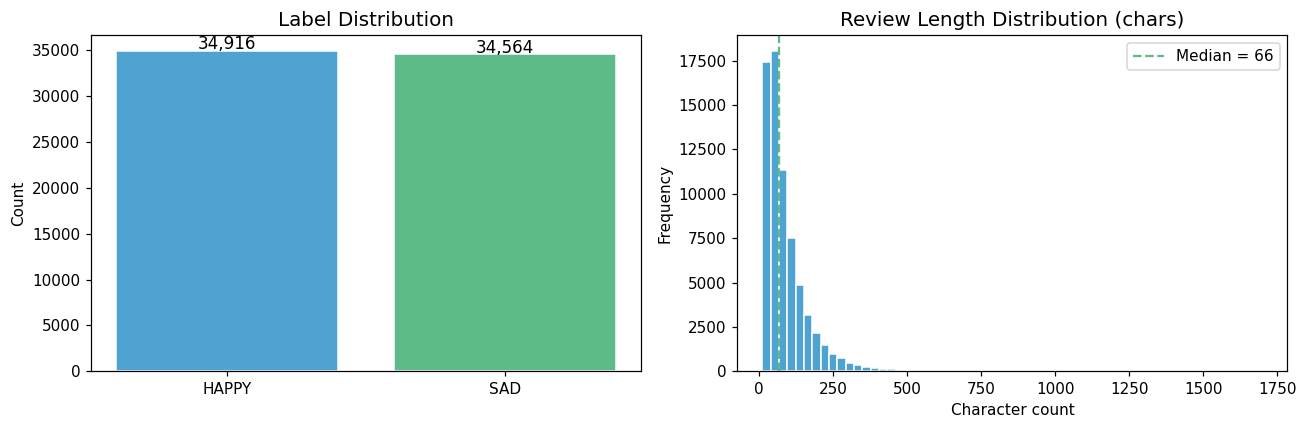


Length stats (chars):
count    69480.0
mean        89.7
std         76.7
min         11.0
25%         39.0
50%         66.0
75%        114.0
max       1700.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
counts = df_raw['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4FA3D1', '#5DBB8A'], edgecolor='white')
axes[0].set_title('Label Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Review length distribution (character count)
df_raw['char_len'] = df_raw['comment'].str.len()
axes[1].hist(df_raw['char_len'], bins=60, color='#4FA3D1', edgecolor='white')
axes[1].set_title('Review Length Distribution (chars)', fontsize=13)
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_raw['char_len'].median(), color='#5DBB8A', linestyle='--', label=f'Median = {df_raw["char_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"\nLength stats (chars):")
print(df_raw['char_len'].describe().round(1).to_string())

In [5]:
# Show 5 raw sample reviews
print("=== Sample raw reviews ===")
for i, row in df_raw.sample(5, random_state=1).iterrows():
    print(f"[{row['label']}] {row['comment']}")
    print()

=== Sample raw reviews ===
[SAD] کیفیت واقعا افت فاحشی داره حیف اون همه خاطره ما از پیتزا پرپروک

[SAD] برخورد پیک بسیار زشت و بی ادبانه بود.

[SAD] کیفیت خیلی بدددد بود - حجم غذا خیلی کم شده - واقعا متاسفم که برای همچین غذای بدرد نخوری پول دادم

[SAD] در توضیحات نوشته بودم فقط ژامبون مرغ محبت کنید بدین معنا که ژامبون گوشت نذارید، نه اینکه ساندویچ رو بدون هیچ مخلافاتی فقط با ژامبون گوشت و مرغ خالی ارسال کنید، غذا خوب بود و ممنونم ازتون که به بقیه نکات توجه کرده بودید!

[HAPPY] ممنون از رفتار بسیار مناسب پیک



## 3. Text Preprocessing

All cleaning logic lives in `src/preprocessing.py`.
Key design decisions:

- **URL removal runs before Hazm normalization** — the normalizer strips `:` and `/`,
  which breaks URL regex if run after.
- **Custom stopword set** — Hazm's default list includes sentiment words like
  خوب (good) and عالی (excellent). We subtract those before filtering.
- **Repeat-char collapse to 1** — خوووب → خوب (not خووب), so lemmatizer
  always sees a valid root form.
- **Lemmatization** returns `past_stem#present_stem` for verbs; we take `[0]`
  (past stem) as the canonical root.

In [6]:
from preprocessing import clean_text, preprocess_dataframe, show_examples

print('Preprocessing pipeline imported.')

Preprocessing pipeline imported.


In [7]:
# This takes ~1-2 minutes on 70k rows (Hazm tokenizer + lemmatizer per row)
print('Running preprocessing... (may take 1-2 min)')
df_clean = preprocess_dataframe(df_raw, text_col='comment', label_col='label')
print(f'Done. Rows after cleaning: {len(df_clean):,}')

Running preprocessing... (may take 1-2 min)


[preprocessing] Dropped 8 rows with empty text after cleaning.
Done. Rows after cleaning: 69,472


## 4. Before / After Examples

In [8]:
# Pick representative examples: positive, negative, with emojis, with repeated chars, with URL
manual_examples = [
    'سلام خیلی خوووووب بود! غذا عالیییی بود ⭐⭐⭐',
    'بدترین تجربه زندگیم بود. اصلا توصیه نمیکنم به هیچ کس',
    'غذا وقتی رسید سرد بوووووود. افتضاح',
    'https://snappfood.ir عالی عالی عالی پیتزا خوشمزه',
    'كيفيت پايين ، قيمت بالا ، تحويل دير',   # Arabic chars (ك ي) before normalization
]

print(f"{'BEFORE':<55} {'AFTER'}")
print('-' * 100)
for raw in manual_examples:
    cleaned = clean_text(raw)
    print(f"{raw[:52]:<55} {cleaned}")
    print()

BEFORE                                                  AFTER
----------------------------------------------------------------------------------------------------
سلام خیلی خوووووب بود! غذا عالیییی بود ⭐⭐⭐              سلام خوب غذا عالی

بدترین تجربه زندگیم بود. اصلا توصیه نمیکنم به هیچ کس    بدترین تجربه زندگیم اصلا توصیه کرد هیچ‌کس

غذا وقتی رسید سرد بوووووود. افتضاح                      غذا سرد بوود افتضاح

https://snappfood.ir عالی عالی عالی پیتزا خوشمزه        عالی عالی عالی پیتزا خوشمزه

كيفيت پايين ، قيمت بالا ، تحويل دير                     کیفیت پایین قیمت تحویل دیر



In [9]:
# Also show 10 random examples from the actual dataset
sample_idx = df_clean.sample(10, random_state=42).index

comparison = pd.DataFrame({
    'Before (raw)':  df_raw.loc[sample_idx, 'comment'].str[:80].values,
    'After (clean)': df_clean.loc[sample_idx, 'cleaned'].str[:80].values,
    'Label':         df_clean.loc[sample_idx, 'label'].values,
})
comparison

,Before (raw),After (clean),Label
0,خیلی تازه و خوشمزس,کیفیت پیتزای سیسیل پرپروک پایین تقریبا نون خالی تحویل,SAD
1,بسته بندی زیبا و غذای خوشمزه.,تاخیر پیتزا سرد,SAD
2,کیفیت نان و برخورد پیک عالی بود پیشنهاد میشه این نان مخصوص حسنلو رو تو چانه‌های,سفارش تقریبا ساعت پیگیری تحویل داد نان سحر خانه صد قدم فاصله,SAD
3,شیرینی مارسبانی کره‌ای رو تا بحال امتحان نکرده بودم ولی برای سلیقه‌ی شخصی من میز,پیتزا شل بد چیش جدا بعدشم دوروز پیتزا خانواده گرفت سیب‌زمینی تومان امروز پیتزا ی,SAD
4,کیفیت غذا مثل همیشه عالی من مشتری دائمی رستوران شما شدم کیفیت غذا عالی,کیفیت عالی موقع,HAPPY
5,عالی بود صرف نظر از اینکه سالم هست یا نه ولی طعمش عالی بود,غذا ساعت سفارش تحویل,SAD
6,از درجه سه‌ترین پنیر و سوسی و کالباس در این پیتزا استفاده شده اصلا پیشنهاد نمیکن,خوش‌طعم تازه طرحشم دقیقا طرح عکس,HAPPY
7,مثل همیشه کامل و پر سرعت,پیتزا خوب طعم گوشت نعنایی عالی کوچیک منو ذکر شد نفره ماهم نفر بود خورد سیر شد یه,HAPPY
8,برنج خارجی و نیم دونه بود کاملا بوی موندگی میداد خورشت هم گوشتش همینطور پیک هم ب,خامه سبک نون نرم خیل سریع رسوندن مرسی,HAPPY
9,طعم خوب بود دور چین هم خوب بود,داغ سریع دستم ممنون,HAPPY


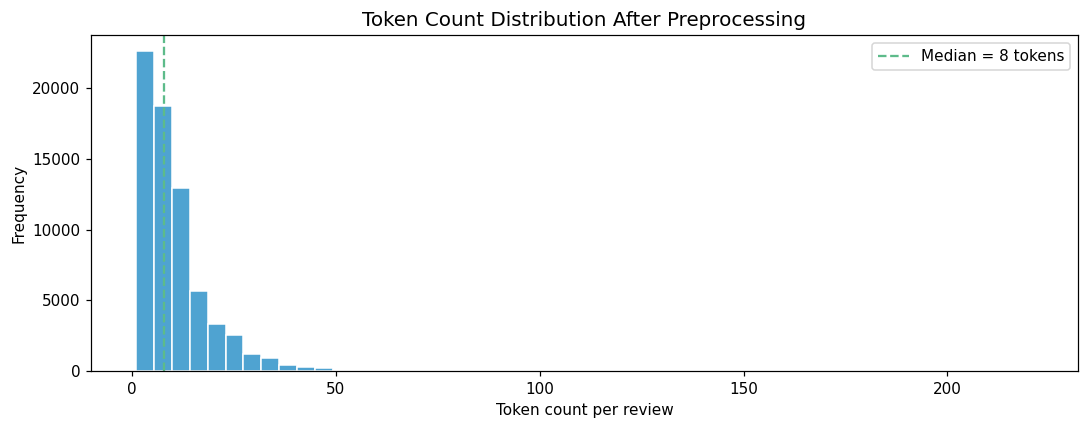

count    69472.0
mean        10.6
std          9.0
min          1.0
25%          5.0
50%          8.0
75%         13.0
max        221.0
Name: token_count, dtype: float64


In [10]:
# Token count distribution after cleaning
df_clean['token_count'] = df_clean['cleaned'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['token_count'], bins=50, color='#4FA3D1', edgecolor='white')
ax.axvline(df_clean['token_count'].median(), color='#5DBB8A', linestyle='--',
           label=f'Median = {df_clean["token_count"].median():.0f} tokens')
ax.set_title('Token Count Distribution After Preprocessing', fontsize=13)
ax.set_xlabel('Token count per review')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'token_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print(df_clean['token_count'].describe().round(1))

## 5. Train / Test Split

**80 / 20 split**, stratified on label to keep class balance identical in both sets.
`random_state=42` for reproducibility.

In [11]:
# Binary encode labels: HAPPY=1, SAD=0
label_map = {'HAPPY': 1, 'SAD': 0}
df_clean['label_enc'] = df_clean['label'].map(label_map)

X = df_clean['cleaned'].values
y = df_clean['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train):,}')
print(f'Test  size : {len(X_test):,}')
print(f'Train HAPPY: {y_train.sum():,} / SAD: {(y_train==0).sum():,}')
print(f'Test  HAPPY: {y_test.sum():,}  / SAD: {(y_test==0).sum():,}')

Train size : 55,577
Test  size : 13,895
Train HAPPY: 27,930 / SAD: 27,647
Test  HAPPY: 6,983  / SAD: 6,912


## 6. Save Processed Data

In [12]:
# Save train and test as CSV (text + label)
train_df = pd.DataFrame({'cleaned': X_train, 'label': y_train})
test_df  = pd.DataFrame({'cleaned': X_test,  'label': y_test})

train_df.to_csv(os.path.join(DATA_PROC, 'train.csv'), index=False, encoding='utf-8')
test_df.to_csv( os.path.join(DATA_PROC, 'test.csv'),  index=False, encoding='utf-8')

# Save label arrays as npy for fast loading in later notebooks
np.save(os.path.join(DATA_PROC, 'y_train.npy'), y_train)
np.save(os.path.join(DATA_PROC, 'y_test.npy'),  y_test)

print('Saved:')
print(f'  data/processed/train.csv  ({len(train_df):,} rows)')
print(f'  data/processed/test.csv   ({len(test_df):,} rows)')
print(f'  data/processed/y_train.npy')
print(f'  data/processed/y_test.npy')

Saved:
  data/processed/train.csv  (55,577 rows)
  data/processed/test.csv   (13,895 rows)
  data/processed/y_train.npy
  data/processed/y_test.npy


## 7. Summary

| Step | Detail |
|---|---|
| Raw dataset | 70,000 reviews (HAPPY / SAD) |
| After cleaning | see output above |
| Train split | 80% — stratified |
| Test split | 20% — stratified |
| Label encoding | HAPPY=1, SAD=0 |
| Saved files | `train.csv`, `test.csv`, `y_train.npy`, `y_test.npy` |

**Next:** Phase 2 — Vectorization (`02_vectorization.ipynb`)